In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from _helper_functions import cb
from _helper_functions import dprint
from _helper_functions import zipdf
from _helper_functions import quickfig

In [2]:
df='data/Supplementary Table 2.tsv'
df=pd.read_csv(df,sep='\t')

df=df.loc[df['WT Activity']!='N.D.',:]
df['WT Activity']=df['WT Activity'].astype(float)
df.head(1)

,Sequence,Sequence-id,Site Order,WT Activity,ABL Sequence,ABL Activity,Syntax Family Label,Syntax Score
0,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,1.2,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.85,Moderate,20


[Text(0, 0, 'Elements in\nRobust Families'),
 Text(1, 0, 'Elements in\nModerate Families'),
 Text(2, 0, 'Elements in\nInert Families')]

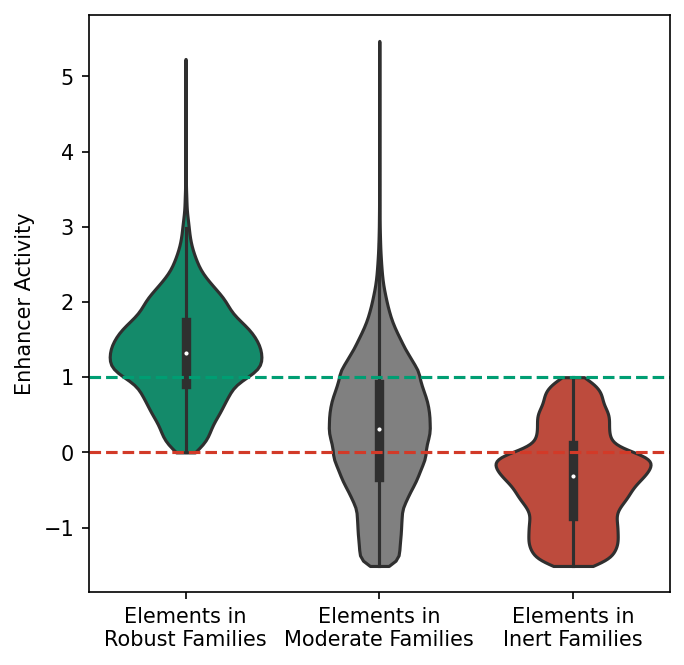

In [3]:
x=df.loc[df['Syntax Family Label']=='Robust','WT Activity']
y=df.loc[df['Syntax Family Label']=='Moderate','WT Activity']
z=df.loc[df['Syntax Family Label']=='Inert','WT Activity']

fig,ax=quickfig()
sns.violinplot(data=[x,y,z],palette=[cb['green'],'grey',cb['orangenature']],cut=0)

ax.axhline(0,ls='--',color=cb['orangenature'])
ax.axhline(1,ls='--',color=cb['green'])

ax.set_ylabel('Enhancer Activity')
ax.set_xticklabels(['Elements in\nRobust Families','Elements in\nModerate Families','Elements in\nInert Families'])


In [4]:
bins = list(range(0,40,2))
df['Syntax Score Binned'],pdbins = pd.cut(df['Syntax Score'], bins=bins, include_lowest=True,right=False,retbins=True)
df['Syntax Score Binned'] = pd.Categorical(df['Syntax Score Binned'], ordered=True)


Text(0.5, 0, 'Syntax Score')

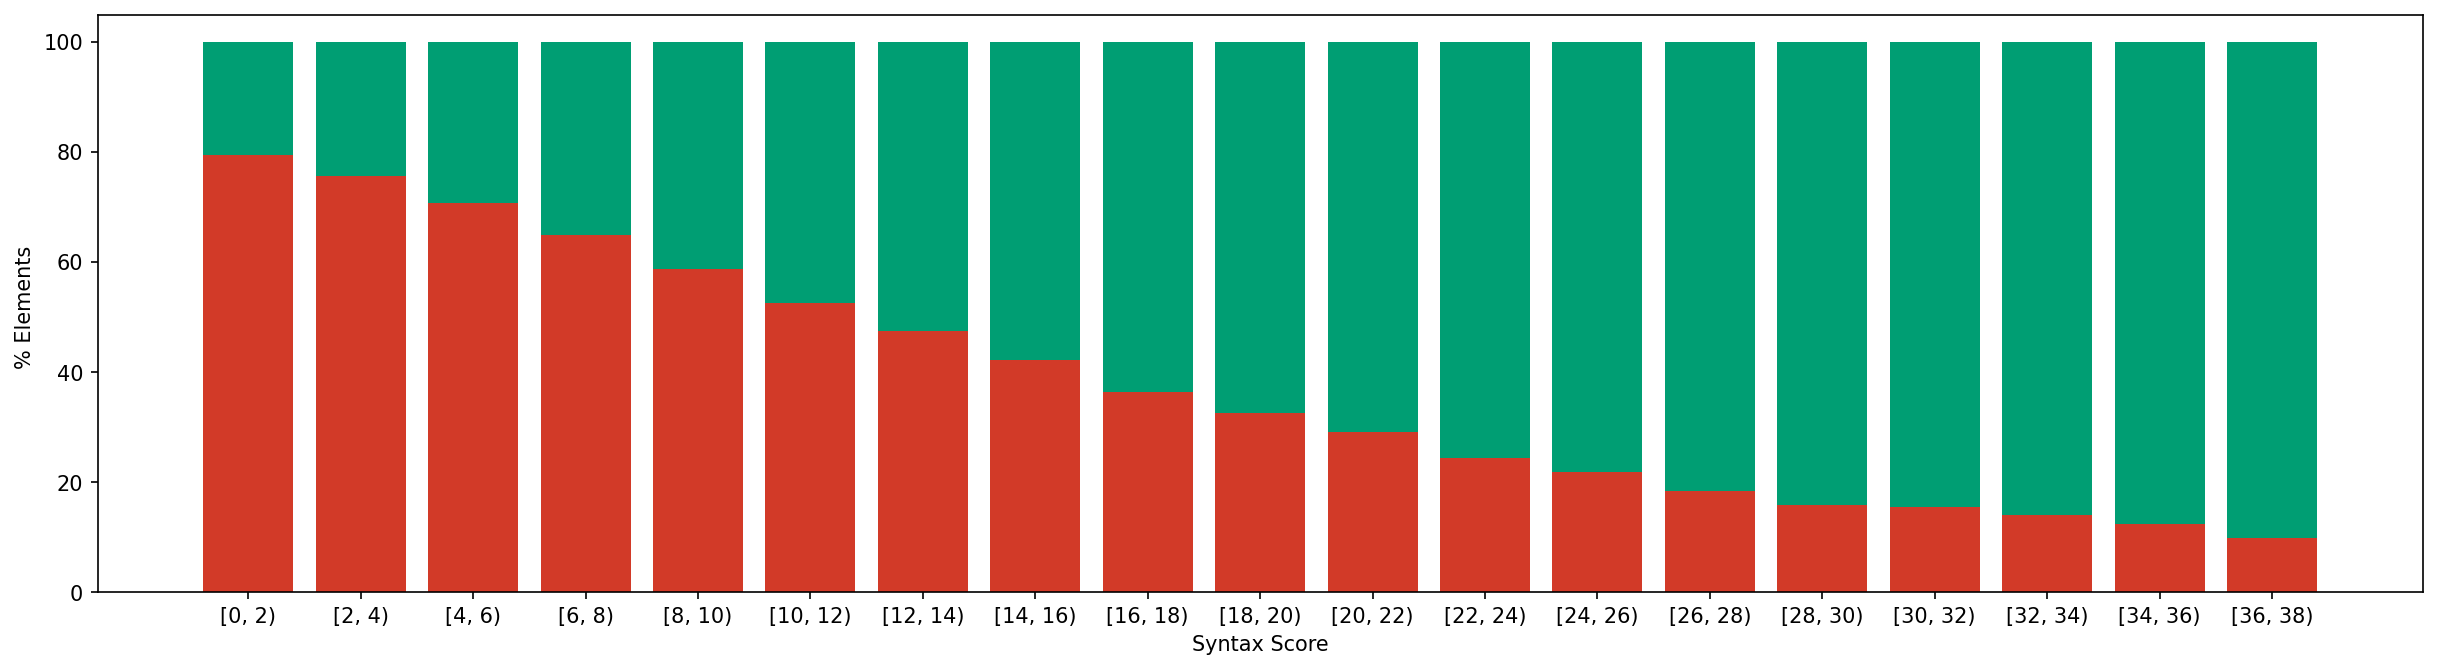

In [5]:

fig,ax=quickfig(20,5)

for i,b in enumerate(df['Syntax Score Binned'].cat.categories):

    thisdf=df.loc[df['Syntax Score Binned']==b,:]
    
    activeElements=sum(thisdf['WT Activity']>=1)
    inertElements =sum(thisdf['WT Activity']<=0)

    n=activeElements+inertElements
    
    activeElements=100*activeElements/n
    inertElements =100*inertElements/n
    

    ax.bar(x=i,height=inertElements,color=cb['orangenature'])
    ax.bar(x=i,height=activeElements,bottom=inertElements,color=cb['green'])

ax.set_xticks(range(len(df['Syntax Score Binned'].cat.categories)),labels=df['Syntax Score Binned'].cat.categories)
ax.set_ylabel('% Elements ')
ax.set_xlabel('Syntax Score')